In [1]:
#0. 작업 준비
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
import re

from sklearn.model_selection import train_test_split

from keras.models import load_model
from keras.callbacks import EarlyStopping,ModelCheckpoint

In [2]:
df=pd.read_csv('spam.csv',encoding='latin1')[['v1','v2']]
len(df)

5572

In [3]:
def 전처리기(문장,불용어_사용유뮤=True):
    문장정리_1차=re.sub('[^a-zA-Z0-9]',' ',문장)
    소문자화_문장=문장정리_1차.lower().split()
    if 불용어_사용유뮤:
        불용어=set(stopwords.words('english'))
        정리된_문장=[단어 for 단어 in 소문자화_문장 if 단어 not in 불용어]
        최종_문장 = ' '.join(정리된_문장)
    else:
        최종_문장 = ' '.join(소문자화_문장)
    return 최종_문장

In [4]:
df['X']=df.v2.apply(lambda x: 전처리기(x))

In [5]:
df=df.drop_duplicates(subset=['X'])
print(len(df))
df.loc[:,'X']=df['X'].replace('[^a-zA-Z0-9 ]','',regex=True)
df.loc[:,'X']=df['X'].replace('^ +','',regex=True)
df.loc[:,'X']=df['X'].replace('',np.nan)
df=df.dropna()
print(len(df))

5107
5106


In [6]:
정답기록=LabelEncoder().fit(df['v1'])
df['y']=정답기록.transform(df['v1'])
df

,v1,v2,X,y
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...,0
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...,1
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though,0
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,2nd time tried 2 contact u u 750 pound prize 2...,1
5568,ham,Will Ì_ b going to esplanade fr home?,b going esplanade fr home,0
5569,ham,"Pity, * was in mood for that. So...any other s...",pity mood suggestions,0
5570,ham,The guy did some bitching but I acted like i'd...,guy bitching acted like interested buying some...,0


In [7]:
X=df['X'].to_numpy()
y=df['y'].to_numpy()

In [8]:
X.shape,y.shape

((5106,), (5106,))

In [9]:
tr_x,tt_x,tr_y,tt_y=train_test_split(X,y,test_size=0.3,random_state=10)
tr_x.shape,tt_x.shape,tr_y.shape,tt_y.shape

((3574,), (1532,), (3574,), (1532,))

In [10]:
tk=Tokenizer()
tk.fit_on_texts(tr_x)

In [11]:
w_n=len([i for i in sorted(tk.word_counts.items(),key=lambda x:x[1]) if i[1]>2])+1

In [12]:
end_tk=Tokenizer(num_words=w_n)
end_tk.fit_on_texts(tr_x)

In [13]:
tk_tr_x=end_tk.texts_to_sequences(tr_x)
tk_tt_x=end_tk.texts_to_sequences(tt_x)

In [14]:
drop_tr_idx=[i for i,v in enumerate(tk_tr_x) if len(v)<1]
drop_tt_idx=[i for i,v in enumerate(tk_tt_x) if len(v)<1]

In [15]:
tk_tr_x=np.array(tk_tr_x,dtype=object)
tk_tt_x=np.array(tk_tt_x,dtype=object)
end_tr_x=np.delete(tk_tr_x,drop_tr_idx,axis=0).tolist()
end_tt_x=np.delete(tk_tt_x,drop_tt_idx,axis=0).tolist()
end_tr_y=np.delete(tr_y,drop_tr_idx,axis=0)
end_tt_y=np.delete(tt_y,drop_tt_idx,axis=0)

In [16]:
len(end_tr_x),len(end_tr_y)

(3540, 3540)

In [17]:
w_l=len(pad_sequences(end_tr_x)[0])

In [18]:
tr_input=pad_sequences(end_tr_x,maxlen=w_l)
tt_input=pad_sequences(end_tt_x,maxlen=w_l)

In [19]:
tr_input.shape,tt_input.shape

((3540, 58), (1513, 58))

In [20]:
#모델 구축
from keras.models import Sequential
from keras.layers import Input,Embedding,LSTM,Dense

In [21]:
w_n

1965

In [43]:
m=Sequential()
m.add(Embedding(w_n,100))
m.add(LSTM(128,dropout=0.5,return_sequences=True))
m.add(LSTM(128,dropout=0.5))
m.add(Dense(1,activation='sigmoid'))

In [45]:
m.compile(optimizer='adam',loss='binary_crossentropy',metrics=['acc'])
ck=ModelCheckpoint('best_m.keras',monitor='val_acc',mode='max',verbose=1,save_best_only=True)
es=EarlyStopping(patience=4,monitor='val_loss',mode='min',verbose=1)
hy=m.fit(tr_input,end_tr_y,epochs=100,callbacks=[ck,es],batch_size=64,validation_split=0.2)

Epoch 1/100
44/45 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - acc: 0.8272 - loss: 0.4054
Epoch 1: val_acc improved from -inf to 0.97458, saving model to best_m.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - acc: 0.8300 - loss: 0.4008 - val_acc: 0.9746 - val_loss: 0.1611
Epoch 2/100
44/45 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - acc: 0.9692 - loss: 0.1358
Epoch 2: val_acc improved from 0.97458 to 0.98588, saving model to best_m.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - acc: 0.9694 - loss: 0.1344 - val_acc: 0.9859 - val_loss: 0.0610
Epoch 3/100
44/45 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - acc: 0.9873 - loss: 0.0418
Epoch 3: val_acc improved from 0.98588 to 0.98729, saving model to best_m.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - acc: 0.9872 - loss: 0.0419 - val_acc: 0.9873 - val_loss: 0.0509
Epoch 4/100
44/45 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - acc: 0.9914 - loss: 0.0318
Epoch 4: val_acc improved from 0.98729 to 0.98870, saving model to best_m.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step 

In [47]:
m.evaluate(tr_input,end_tr_y),m.evaluate(tt_input,end_tt_y)

111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.9994 - loss: 0.0038
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9829 - loss: 0.0855


([0.016773905605077744, 0.9968926310539246],
 [0.09848573803901672, 0.9801718592643738])

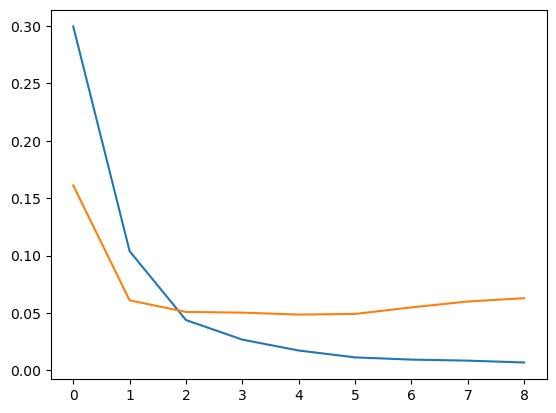

In [49]:
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])

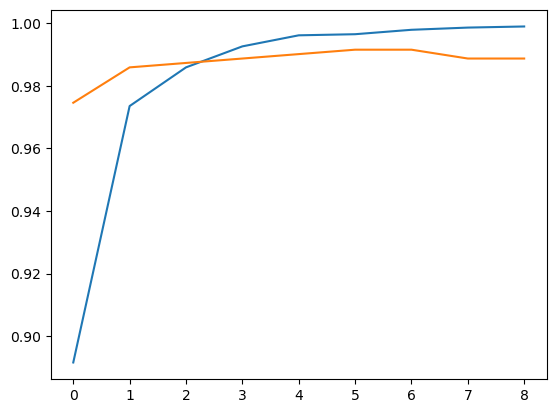

In [51]:
plt.plot(hy.history['acc'])
plt.plot(hy.history['val_acc'])

In [57]:
l_m=load_model('best_m.keras')
l_m.evaluate(tr_input,end_tr_y)

111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.9989 - loss: 0.0051


[0.01605171523988247, 0.9968926310539246]

In [67]:
정답기록.inverse_transform([0])

array(['ham'], dtype=object)

In [59]:
end_tr_y

array([0, 0, 0, ..., 0, 0, 0])

In [69]:
def 문장_전처리(문장):
    문장=전처리기(문장)
    e_문장=end_tk.texts_to_sequences([문장])
    p_문장=pad_sequences(e_문장,maxlen=w_l)
    점수=float(l_m.predict(p_문장).item())
    if (점수>0.5):
        print(f"{점수*100:.2f}%확률로 스팸입니다.")
    else:
        print(f"{(1-점수)*100:.2f}%확률로 정상입니다.")

In [97]:
tt_y[207]

0

In [95]:
tt_x[207]

'u better go sleep dun disturb u liao u wake msg lor'

In [99]:
문장_전처리(tt_x[207])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
99.98%확률로 정상입니다.


In [81]:
문장_전처리(df.v2[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
99.98%확률로 정상입니다.


# Q2 IMDB 데이터를 통하여 텍스트 분석하여 결과를 도출하시오

In [124]:
import pandas as pd
df=pd.read_csv('IMDB Dataset.csv')

In [125]:
from bs4 import BeautifulSoup
#마크업_처리된_text=BeautifulSoup(text,'lxml').get_text()

In [126]:
def 전처리기(문장,불용어_사용유뮤=True):
    문장=BeautifulSoup(문장,'lxml').get_text()
    문장정리_1차=re.sub('[^a-zA-Z0-9 ]',' ',문장)
    소문자화_문장=문장정리_1차.lower().split()
    if 불용어_사용유뮤:
        불용어=set(stopwords.words('english'))
        정리된_문장=[단어 for 단어 in 소문자화_문장 if 단어 not in 불용어]
        최종_문장 = ' '.join(정리된_문장)
    else:
        최종_문장 = ' '.join(소문자화_문장)
    return 최종_문장

In [127]:
df['X']=df.review.apply(lambda x: 전처리기(x))

C:\Users\gurwl\AppData\Local\Temp\ipykernel_4680\1937160882.py:2: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  문장=BeautifulSoup(문장,'lxml').get_text()


In [128]:
정답기록=LabelEncoder().fit(df['sentiment'])
df['y']=정답기록.transform(df['sentiment'])

In [132]:
df=df.drop_duplicates(subset=['X'])
df.loc[:,'X']=df['X'].replace('[^a-zA-Z0-9 ]','',regex=True)
df.loc[:,'X']=df['X'].replace('^ +','',regex=True)
df.loc[:,'X']=df['X'].replace('',np.nan)
df=df.dropna()

In [133]:
X=df['X'].to_numpy()
y=df['y'].to_numpy()
tr_x,tt_x,tr_y,tt_y=train_test_split(X,y,test_size=0.3,random_state=10)

In [134]:
tk=Tokenizer()
tk.fit_on_texts(tr_x)

In [135]:
w_n=len([i for i in sorted(tk.word_counts.items(),key=lambda x:x[1]) if i[1]>2])+1

In [136]:
end_tk=Tokenizer(num_words=w_n)
end_tk.fit_on_texts(tr_x)

In [137]:
tk_tr_x=end_tk.texts_to_sequences(tr_x)
tk_tt_x=end_tk.texts_to_sequences(tt_x)

In [138]:
drop_tr_idx=[i for i,v in enumerate(tk_tr_x) if len(v)<1]
drop_tt_idx=[i for i,v in enumerate(tk_tt_x) if len(v)<1]

In [139]:
tk_tr_x=np.array(tk_tr_x,dtype=object)
tk_tt_x=np.array(tk_tt_x,dtype=object)
end_tr_x=np.delete(tk_tr_x,drop_tr_idx,axis=0).tolist()
end_tt_x=np.delete(tk_tt_x,drop_tt_idx,axis=0).tolist()
end_tr_y=np.delete(tr_y,drop_tr_idx,axis=0)
end_tt_y=np.delete(tt_y,drop_tt_idx,axis=0)

In [221]:
w_l=len(pad_sequences(end_tr_x)[0])

In [223]:
w_l

1109

In [141]:
w_l=100

In [142]:
tr_input=pad_sequences(end_tr_x,maxlen=w_l)
tt_input=pad_sequences(end_tt_x,maxlen=w_l)

In [143]:
m=Sequential()
m.add(Embedding(w_n,100))
m.add(LSTM(128,dropout=0.5,return_sequences=True))
m.add(LSTM(128,dropout=0.5))
m.add(Dense(1,activation='sigmoid'))

In [144]:
m.compile(optimizer='adam',loss='binary_crossentropy',metrics=['acc'])
ck=ModelCheckpoint('best_m.keras',monitor='val_acc',mode='max',verbose=1,save_best_only=True)
es=EarlyStopping(patience=4,monitor='val_loss',mode='min',verbose=1)
hy=m.fit(tr_input,end_tr_y,epochs=100,callbacks=[ck,es],batch_size=64,validation_split=0.2)

Epoch 1/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - acc: 0.7613 - loss: 0.4594
Epoch 1: val_acc improved from -inf to 0.87999, saving model to best_m.keras
434/434 ━━━━━━━━━━━━━━━━━━━━ 88s 188ms/step - acc: 0.7615 - loss: 0.4592 - val_acc: 0.8800 - val_loss: 0.2908
Epoch 2/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - acc: 0.9352 - loss: 0.1742
Epoch 2: val_acc did not improve from 0.87999
434/434 ━━━━━━━━━━━━━━━━━━━━ 78s 181ms/step - acc: 0.9352 - loss: 0.1742 - val_acc: 0.8735 - val_loss: 0.3341
Epoch 3/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - acc: 0.9687 - loss: 0.0953
Epoch 3: val_acc did not improve from 0.87999
434/434 ━━━━━━━━━━━━━━━━━━━━ 79s 182ms/step - acc: 0.9687 - loss: 0.0953 - val_acc: 0.8689 - val_loss: 0.3684
Epoch 4/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - acc: 0.9764 - loss: 0.0730
Epoch 4: val_acc did not improve from 0.87999
434/434 ━━━━━━━━━━━━━━━━━━━━ 80s 183ms/step - acc: 0.9764 - loss: 0.0730 - val_acc: 0.8630 - val_loss: 0.5078
Epoch 5/1

In [181]:
l_m=load_model('best_m.keras')
l_m.evaluate(tr_input,end_tr_y),l_m.evaluate(tt_input,end_tt_y)

1085/1085 ━━━━━━━━━━━━━━━━━━━━ 39s 36ms/step - acc: 0.9450 - loss: 0.1752
465/465 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - acc: 0.8800 - loss: 0.2893


([0.1983855962753296, 0.9324823021888733],
 [0.2902034819126129, 0.8799166083335876])

In [207]:
def 문장_전처리(문장):
    문장=전처리기(문장)
    e_문장=end_tk.texts_to_sequences([문장])
    p_문장=pad_sequences(e_문장,maxlen=w_l)
    점수=float(l_m.predict(p_문장).item())
    if (점수>0.5):
        print(f"{점수*100:.2f}%확률로 긍정리뷰 입니다.")
    else:
        print(f"{(1-점수)*100:.2f}%확률로 부정리뷰 입니다.")

In [209]:
정답기록.classes_

array(['negative', 'positive'], dtype=object)

In [211]:
tt_y[207]

1

In [213]:
tt_x[207]

'intents purposes teen devian might seem like another lightweight bollywood musical extent might even true especially producers sure film succeeded masses somewhere behind scenes either sadashiv brahmam idea story amerjeet directed film decided would twist usual formula succeeded perhaps beyond even expectations simply handsome man flirting 3 women undecided choose life partner dev anand character really love 3 women various times despite aware two dev anand relationship simi kalpana particularly interesting women comes depend heavily quite lot suggestive teasers stars body language lend imagination depending viewer maturity theme surprisingly adult ashame ending tame obviously designed please masses deflect criticism'

In [215]:
문장_전처리(tt_x[207])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
68.84%확률로 부정리뷰 입니다.


In [217]:
문장_전처리(tt_x[100])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
96.54%확률로 긍정리뷰 입니다.


In [219]:
tt_y[100]

1

In [227]:
!pip install soynlp

In [229]:
!pip install https://github.com/haven-jeon/PyKoSpacing/archive/refs/heads/master.zip

  Using cached https://github.com/haven-jeon/PyKoSpacing/archive/refs/heads/master.zip
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


In [233]:
from pykospacing import Spacing#한국어 전처리기
text='안녕하세요저는강사입니다오늘수업은다들열심히듣고있어서힘이나네요.'

In [235]:
ck=Spacing()
ck(text)

'안녕하세 요저는 강사입니다 오늘 수업은 다들 열심히 듣고 있어서 힘이나네요.'

In [1]:
import soynlp

In [2]:
from soynlp import DoublespaceLineCorpus
from soynlp.word import WordExtractor

In [3]:
import urllib.request
urllib.request.urlretrieve('https://raw.githubusercontent.com/lovit/soynlp/master/tutorials/2016-10-20.txt',filename='2016-10-20.txt')

('2016-10-20.txt', <http.client.HTTPMessage at 0x16e210c4a40>)

In [4]:
corpus=DoublespaceLineCorpus('2016-10-20.txt')
corpus

In [257]:
n=0
for document in corpus:
    n+=1
    if len(document):
        print(document)
    if n==3:
        break
   

19  1990  52 1 22
오패산터널 총격전 용의자 검거 서울 연합뉴스 경찰 관계자들이 19일 오후 서울 강북구 오패산 터널 인근에서 사제 총기를 발사해 경찰을 살해한 용의자 성모씨를 검거하고 있다 성씨는 검거 당시 서바이벌 게임에서 쓰는 방탄조끼에 헬멧까지 착용한 상태였다 독자제공 영상 캡처 연합뉴스  서울 연합뉴스 김은경 기자 사제 총기로 경찰을 살해한 범인 성모 46 씨는 주도면밀했다  경찰에 따르면 성씨는 19일 오후 강북경찰서 인근 부동산 업소 밖에서 부동산업자 이모 67 씨가 나오기를 기다렸다 이씨와는 평소에도 말다툼을 자주 한 것으로 알려졌다  이씨가 나와 걷기 시작하자 성씨는 따라가면서 미리 준비해온 사제 총기를 이씨에게 발사했다 총알이 빗나가면서 이씨는 도망갔다 그 빗나간 총알은 지나가던 행인 71 씨의 배를 스쳤다  성씨는 강북서 인근 치킨집까지 이씨 뒤를 쫓으며 실랑이하다 쓰러뜨린 후 총기와 함께 가져온 망치로 이씨 머리를 때렸다  이 과정에서 오후 6시 20분께 강북구 번동 길 위에서 사람들이 싸우고 있다 총소리가 났다 는 등의 신고가 여러건 들어왔다  5분 후에 성씨의 전자발찌가 훼손됐다는 신고가 보호관찰소 시스템을 통해 들어왔다 성범죄자로 전자발찌를 차고 있던 성씨는 부엌칼로 직접 자신의 발찌를 끊었다  용의자 소지 사제총기 2정 서울 연합뉴스 임헌정 기자 서울 시내에서 폭행 용의자가 현장 조사를 벌이던 경찰관에게 사제총기를 발사해 경찰관이 숨졌다 19일 오후 6시28분 강북구 번동에서 둔기로 맞았다 는 폭행 피해 신고가 접수돼 현장에서 조사하던 강북경찰서 번동파출소 소속 김모 54 경위가 폭행 용의자 성모 45 씨가 쏜 사제총기에 맞고 쓰러진 뒤 병원에 옮겨졌으나 숨졌다 사진은 용의자가 소지한 사제총기  신고를 받고 번동파출소에서 김창호 54 경위 등 경찰들이 오후 6시 29분께 현장으로 출동했다 성씨는 그사이 부동산 앞에 놓아뒀던 가방을 챙겨 오패산 쪽으로 도망간 후였다  김 경위는 오패산 터널 입구 오른쪽의 급경사에서 성씨에

In [9]:
w_ex=WordExtractor()
w_ex.train(corpus)

training was done. used memory 0.696 Gb


In [10]:
w_sc_table=w_ex.extract()

all cohesion probabilities was computed. # words = 223348
all branching entropies was computed # words = 361598
all accessor variety was computed # words = 361598


In [12]:
w_sc_table['반포한강'].cohesion_forward

0.19841268168224552

In [13]:
w_sc_table['반포한강공'].cohesion_forward

0.2972877884078849

In [14]:
w_sc_table['반포한강공원'].cohesion_forward

0.37891487632839754

In [15]:
w_sc_table['반포한강공원에'].cohesion_forward

0.33492963377557666

In [23]:
w_sc_table['디스'].right_branching_entropy

1.6371694761537934

In [25]:
w_sc_table['디스플'].right_branching_entropy

-0.0

In [27]:
w_sc_table['디스플레'].right_branching_entropy

-0.0

In [29]:
w_sc_table['디스플레이'].right_branching_entropy

3.1400392861792916

In [31]:
w_sc_table

{'락': Scores(cohesion_forward=0, cohesion_backward=0, left_branching_entropy=2.4251041124565353, right_branching_entropy=4.076460782749974, left_accessor_variety=26, right_accessor_variety=110, leftside_frequency=47, rightside_frequency=851),
 '턴': Scores(cohesion_forward=0, cohesion_backward=0, left_branching_entropy=1.4340412117202102, right_branching_entropy=3.6376032788330153, left_accessor_variety=18, right_accessor_variety=107, leftside_frequency=22, rightside_frequency=1778),
 '슘': Scores(cohesion_forward=0, cohesion_backward=0, left_branching_entropy=0, right_branching_entropy=1.913177293211589, left_accessor_variety=0, right_accessor_variety=8, leftside_frequency=0, rightside_frequency=36),
 '룬': Scores(cohesion_forward=0, cohesion_backward=0, left_branching_entropy=-0.0, right_branching_entropy=3.340328005332897, left_accessor_variety=1, right_accessor_variety=35, leftside_frequency=0, rightside_frequency=216),
 'ㄱ': Scores(cohesion_forward=0, cohesion_backward=0, left_branch

In [33]:
from soynlp.tokenizer import LTokenizer
sc={단어:점수.cohesion_forward for 단어,점수 in w_sc_table.items()}
l_tk=LTokenizer(scores=sc)

In [47]:
l_tk.tokenize('국제사회와 우리의 노력으로 범죄를 척결하자')

['국제사회', '와', '우리', '의', '노력', '으로', '범죄', '를', '척결', '하자']

In [49]:
from soynlp.tokenizer import MaxScoreTokenizer
max_tk=MaxScoreTokenizer(scores=sc)
l_tk.tokenize('국제사회와우리의노력으로범죄를척결하자')

['국제사회', '와우리의노력으로범죄를척결하자']

In [51]:
max_tk.tokenize('국제사회와우리의노력으로범죄를척결하자')

['국제사회', '와', '우리', '의', '노력', '으로', '범죄', '를', '척결', '하자']

In [69]:
from soynlp.normalizer import *
print(emoticon_normalize('유유유유유유유 오늘 수업을 다들 열심히 듣고있어 하하하하하하 ㅠㅠㅠㅠㅠㅠ',num_repeats=3))
print(emoticon_normalize('유유유유 오늘 수업을 다들 열심히 듣고있어 하하하 ㅠㅠㅠㅠㅠㅠㅠㅠ',num_repeats=3))
print(emoticon_normalize('유유유유유 오늘 수업을 다들 열심히 듣고있어 하 ㅠㅠㅠㅠㅠㅠㅠㅠㅠ',num_repeats=3))

유유유 오늘 수업을 다들 열심히 듣고있어 하하하 ㅠㅠㅠ
유유유 오늘 수업을 다들 열심히 듣고있어 하하하 ㅠㅠㅠ
유유유 오늘 수업을 다들 열심히 듣고있어 하 ㅠㅠㅠ


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rc('font',family='NanumGothic')
df=pd.read_table('data2.txt')[['document'	,'label']]

In [3]:
df

,document,label
0,아 더빙.. 진짜 짜증나네요 목소리,0
1,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,너무재밓었다그래서보는것을추천한다,0
3,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1
...,...,...
149995,인간이 문제지.. 소는 뭔죄인가..,0
149996,평점이 너무 낮아서...,1
149997,이게 뭐요? 한국인은 거들먹거리고 필리핀 혼혈은 착하다?,0
149998,청춘 영화의 최고봉.방황과 우울했던 날들의 자화상,1


In [4]:
from konlpy.tag import Okt

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   document  149995 non-null  object
 1   label     150000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.3+ MB


In [11]:
ck_df=df.dropna()
ck_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149995 entries, 0 to 149999
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   document  149995 non-null  object
 1   label     149995 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.4+ MB


In [13]:
X=ck_df['document']

In [15]:
text_data=' '.join(X)

In [17]:
len(text_data)

5430497

In [124]:
from nltk import Text
from tqdm import tqdm
X=ck_df['document']

okt=Okt()
def 명사추출(text):
    l=[]
    for i in tqdm(text):
        단어추출=okt.nouns(i)
        l.extend(단어추출)
    return Text(l)
text_in=명사추출(X)

100%|█████████████████████████████████████████████████████████████████████████| 149995/149995 [07:26<00:00, 335.92it/s]


In [99]:
!pip install wordcloud

In [21]:
from wordcloud import WordCloud
wc=WordCloud(font_path='NanumGothic',width=800,height=400)
#wc_img=wc.generate_from_frequencies(text_in.vocab())

In [137]:
text_in.vocab()

FreqDist({'영화': 50737, '정말': 9645, '진짜': 8343, '이': 8001, '점': 7930, '연기': 6434, '평점': 6324, '것': 6315, '최고': 6035, '스토리': 5344, ...})

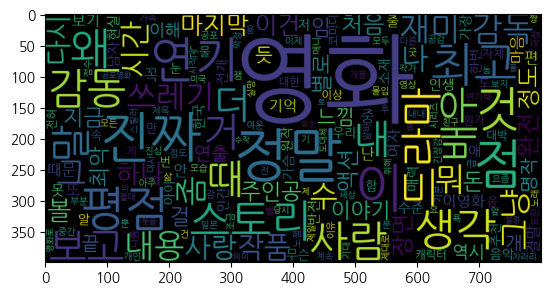

In [138]:
plt.imshow(wc_img)

(-0.5, 799.5, 399.5, -0.5)

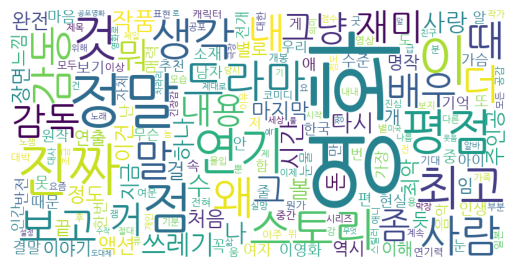

In [144]:
wc=WordCloud(font_path='NanumGothic',width=800,height=400,background_color='white')#워드클라우드 설정
wc_img=wc.generate_from_frequencies(text_in.vocab())#빈도수 내용을 포함한 정확한 워드클라우드 생성 
plt.imshow(wc_img)
plt.axis('off')

In [19]:
text_data=' '.join(ck_df[ck_df.label==0].document)

,document,label
0,아 더빙.. 진짜 짜증나네요 목소리,0
2,너무재밓었다그래서보는것을추천한다,0
3,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
5,막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화.ㅋㅋㅋ...별반개도 아까움.,0
6,원작의 긴장감을 제대로 살려내지못했다.,0
...,...,...
149990,이걸 영화라고 찎었냐?,0
149992,공포나 재난영화가 아니라 아예 대놓고 비급 크리쳐개그물임ㅋㅋ 음악 완전 흥겹다ㅋ 5...,0
149995,인간이 문제지.. 소는 뭔죄인가..,0
149997,이게 뭐요? 한국인은 거들먹거리고 필리핀 혼혈은 착하다?,0


In [27]:
wc=WordCloud(font_path='NanumGothic',width=800,height=400,background_color='white',max_words=10)
wc_img=wc.generate_from_text(text_data)

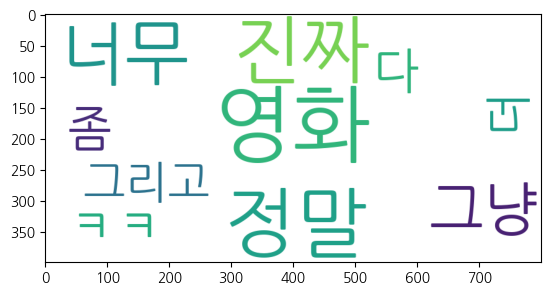

In [28]:
import matplotlib.pyplot as plt
plt.imshow(wc_img)

# Q 코퍼스를 라벨기준으로 분할하여 코퍼스간의 키워드 차이를 구분하시오 단 명사추출을 이용하시오

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pd

In [34]:
ck_df=df.dropna()

In [36]:
X1=ck_df[ck_df['label']==0]['document']
X2=ck_df[ck_df['label']==1]['document']

In [40]:
from nltk import Text
from tqdm import tqdm
okt=Okt()
def 명사추출(text):
    l=[]
    for i in tqdm(text):
        단어추출=okt.nouns(i)
        l.extend(단어추출)
    return Text(l)


In [41]:
text_in1=명사추출(X1)
text_in2=명사추출(X2)

100%|███████████████████████████████████████████████████████████████████████████| 75170/75170 [04:13<00:00, 296.97it/s]


(-0.5, 799.5, 399.5, -0.5)

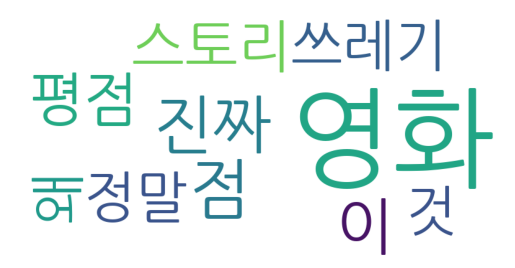

In [60]:
wc=WordCloud(font_path='NanumGothic',width=800,height=400,background_color='white',max_words=10)
plt.imshow(wc.generate_from_frequencies(text_in1.vocab()))
plt.axis('off')

(-0.5, 799.5, 399.5, -0.5)

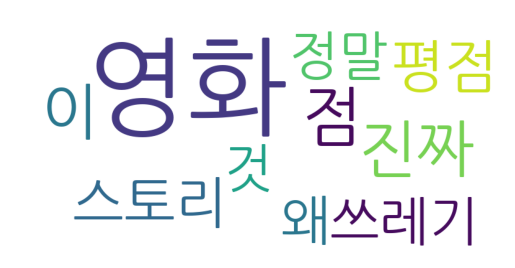

In [58]:
wc=WordCloud(font_path='NanumGothic',width=800,height=400,background_color='white',max_words=10)
plt.imshow(wc.generate_from_frequencies(text_in2.vocab()))
plt.axis('off')

In [62]:
stop_w=set()
stop_w.add('영화')

In [66]:
from wordcloud import STOPWORDS
STOPWORDS

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'all',
 'also',
 'am',
 'an',
 'and',
 'any',
 'are',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 "can't",
 'cannot',
 'com',
 'could',
 "couldn't",
 'did',
 "didn't",
 'do',
 'does',
 "doesn't",
 'doing',
 "don't",
 'down',
 'during',
 'each',
 'else',
 'ever',
 'few',
 'for',
 'from',
 'further',
 'get',
 'had',
 "hadn't",
 'has',
 "hasn't",
 'have',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'hence',
 'her',
 'here',
 "here's",
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 "how's",
 'however',
 'http',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'k',
 "let's",
 'like',
 'me',
 'more',
 'most',
 "mustn't",
 'my',
 'myself',
 'no',
 'nor',
 'not',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'otherwise',
 'ought',
 'our',
 

In [80]:
text_in2.vocab()

FreqDist({'영화': 24598, '점': 4573, '진짜': 4333, '이': 4132, '평점': 3639, '스토리': 3481, '왜': 3356, '쓰레기': 3346, '정말': 3259, '것': 3160, ...})

(-0.5, 799.5, 399.5, -0.5)

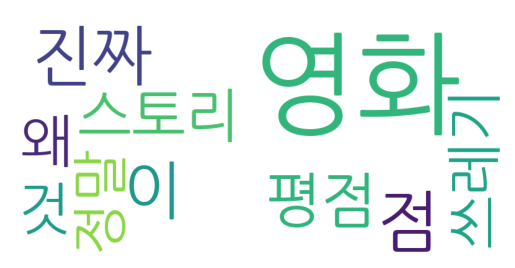

In [86]:
wc=WordCloud(font_path='NanumGothic',width=800,height=400,background_color='white',max_words=10,stopwords=stop_w)
plt.imshow(wc.generate_from_frequencies(text_in2.vocab()))
plt.axis('off')

In [70]:
stop_w

{'영화'}

In [118]:
X1=ck_df[ck_df['label']==0]['document']
X2=ck_df[ck_df['label']==1]['document']

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 39.47it/s]


(-0.5, 799.5, 399.5, -0.5)

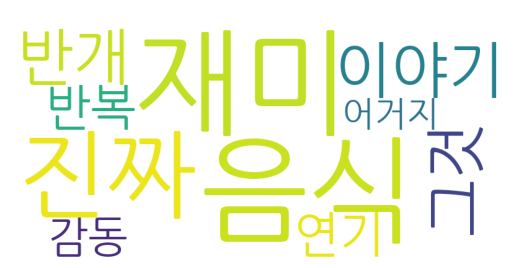

In [120]:
from nltk import Text
from tqdm import tqdm
okt=Okt()
def 명사추출(text):
    l=[]
    for i in tqdm(text):
        단어추출=okt.nouns(i)
        l.append(' '.join(단어추출))
    return ' '.join(l)
#텍스트 데이터 1차 내용 확인 목적
ck_text_data=명사추출(X1.iloc[:10])
wc=WordCloud(font_path='NanumGothic',width=800,height=400,background_color='white',max_words=10,stopwords=stop_w)
plt.imshow(wc.generate_from_text(ck_text_data))
plt.axis('off')

In [126]:
from sklearn.feature_extraction.text import CountVectorizer
def N_그램화(글자문서,표현_단어갯수,n그램값):
  tv=CountVectorizer(ngram_range=(n그램값,n그램값)).fit(글자문서)
  BoW=tv.transform(글자문서)
  sum_BoW=BoW.sum(axis=0)
  w_f=[(w,sum_BoW[0,i])for w,i in tv.vocabulary_.items()]
  w_f=sorted(w_f,key=lambda x:x[1],reverse=True)
  return w_f[:표현_단어갯수]

In [132]:
ck_data1=N_그램화(X1,10,1)

In [133]:
ck_data1

[('영화', 8640),
 ('너무', 4067),
 ('진짜', 3515),
 ('정말', 2847),
 ('그냥', 2663),
 ('이런', 2016),
 ('이건', 1669),
 ('쓰레기', 1541),
 ('영화는', 1477),
 ('없다', 1454)]

In [134]:
ck_data2=N_그램화(X1,10,2)
ck_data2

[('최악의 영화', 317),
 ('보는 내내', 312),
 ('쓰레기 영화', 299),
 ('없는 영화', 240),
 ('재미도 없고', 233),
 ('1점도 아깝다', 219),
 ('아까운 영화', 210),
 ('이런 영화를', 145),
 ('평점이 너무', 142),
 ('이런 영화', 122)]

In [142]:
N_그램화(ck_df.document,10,1)

[('영화', 19041),
 ('너무', 8569),
 ('정말', 8542),
 ('진짜', 6692),
 ('그냥', 3602),
 ('이런', 3486),
 ('영화를', 2838),
 ('보고', 2632),
 ('ㅋㅋ', 2558),
 ('영화는', 2517)]

In [144]:
N_그램화(ck_df.document,10,2)

[('보는 내내', 614),
 ('최고의 영화', 506),
 ('좋은 영화', 367),
 ('최악의 영화', 317),
 ('없는 영화', 312),
 ('평점이 너무', 310),
 ('쓰레기 영화', 301),
 ('있는 영화', 280),
 ('이런 영화', 240),
 ('이런 영화를', 237)]

In [145]:
N_그램화(ck_df.document,10,3)

[('인생 최고의 영화', 63),
 ('tv 전기세가 아깝다', 61),
 ('여운이 남는 영화', 58),
 ('영화 보는 내내', 58),
 ('평점이 너무 높다', 49),
 ('많은 생각을 하게', 48),
 ('재미도 없고 감동도', 47),
 ('기대 안하고 봤는데', 46),
 ('강추 강추 강추', 46),
 ('없고 감동도 없고', 44)]

In [148]:
from sklearn.feature_extraction.text import CountVectorizer

In [150]:
from nltk import bigrams,word_tokenize
from nltk.util import ngrams

In [152]:
s='I am a boy'
tk_w=word_tokenize(s)
tk_w

['I', 'am', 'a', 'boy']

In [156]:
list(ngrams(tk_w,2))

[('I', 'am'), ('am', 'a'), ('a', 'boy')]

In [162]:
list(ngrams(tk_w,2,pad_left=True,left_pad_symbol='SS',pad_right=True,right_pad_symbol='SE'))

[('SS', 'I'), ('I', 'am'), ('am', 'a'), ('a', 'boy'), ('boy', 'SE')]

In [192]:
import nltk
nltk.download('movie_reviews')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\gurwl\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


True

In [170]:
from nltk import ConditionalFreqDist

In [174]:
ng=ngrams(tk_w,2,pad_left=True,left_pad_symbol='SS',pad_right=True,right_pad_symbol='SE')

In [176]:
fd=ConditionalFreqDist([(i,j) for i,j in ng])

In [182]:
fd.conditions()

['SS', 'I', 'am', 'a', 'boy']

In [184]:
fd['SS']

FreqDist({'I': 1})

In [201]:
from nltk.corpus import movie_reviews
data_l=[]
for 문장 in movie_reviews.sents():
    ng_d=ngrams(문장,2,pad_left=True,left_pad_symbol='SS',pad_right=True,right_pad_symbol='SE')
    data_l+=[x for x in ng_d]
cfd=ConditionalFreqDist(data_l)

In [207]:
cfd['SS'].most_common(10)

[('the', 8071),
 ('.', 3173),
 ('it', 3136),
 ('i', 2471),
 ('but', 1814),
 ('and', 1735),
 ('he', 1672),
 ('in', 1659),
 ('this', 1651),
 ('there', 1298)]

In [209]:
cfd['the'].most_common(10)

[('film', 4542),
 ('movie', 2147),
 ('story', 985),
 ('most', 945),
 ('first', 902),
 ('same', 774),
 ('only', 665),
 ('end', 664),
 ('best', 642),
 ('audience', 620)]

In [211]:
cfd['film'].most_common(10)

[(',', 1277),
 ('.', 1118),
 ('is', 895),
 ("'", 583),
 ('that', 332),
 ('was', 195),
 ('and', 154),
 ('has', 152),
 ('in', 138),
 ('to', 118)]

In [213]:
cfd[','].most_common(10)

[('and', 9090),
 ('but', 5293),
 ('the', 4568),
 ('"', 2308),
 ('a', 2152),
 ('it', 2049),
 ('who', 1600),
 ('i', 1562),
 ('he', 1398),
 ('as', 1241)]

In [215]:
cfd['and'].most_common(10)

[('the', 2470),
 ('a', 1028),
 ('his', 680),
 ('it', 589),
 ('i', 481),
 (',', 429),
 ('that', 386),
 ('then', 381),
 ('he', 370),
 ('is', 368)]

In [219]:
cfd['.'].most_common(10)

[('SE', 63404), ('"', 1854), (')', 535), ("'", 70), (']', 10), ("''", 3)]

In [221]:
cfd['SE'].most_common(10)

[]

In [227]:
from nltk.probability import ConditionalFreqDist#문맥별 단어 빈도수
from nltk.probability import ConditionalProbDist #조건부 확률
from nltk.probability import MLEProbDist #최대우도추정